In [7]:
import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse import hstack, kron, eye, csc_matrix, block_diag
import time
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.fitting import tensor_network_distance
from ncon import ncon
import torch
import warnings
import torch.optim as optim
from quimb.tensor import tensor_split
import cotengra as ctg
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

fsize = 24
tsize = 24

tdir = 'in'
major = 7.5
minor = 4.5

style = 'default'

plt.style.use(style)
plt.rcParams['text.usetex'] = False
plt.rcParams['font.size'] = fsize
plt.rcParams['legend.fontsize'] = tsize
plt.rcParams['xtick.direction'] = tdir
plt.rcParams['ytick.direction'] = tdir
plt.rcParams['xtick.major.size'] = major
plt.rcParams['xtick.minor.size'] = minor
plt.rcParams['ytick.major.size'] = major
plt.rcParams['ytick.minor.size'] = minor
plt.rcParams["figure.figsize"] = (16,9)
plt.rcParams['axes.grid']=False
plt.rcParams['grid.alpha'] = 0.25
#mpl.rcParams.update({"axes.grid" : True, "grid.alpha": 0.25})
plt.rcParams['figure.dpi'] = 400
plt.rcParams['text.usetex'] = True
from matplotlib.colors import LinearSegmentedColormap
num_colors = 7
# Define the start and end colors (e.g., blue to red)
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", ["blue", "red"])
# Sample from your custom colormap
c_list = [custom_cmap(i) for i in np.linspace(0, 1, num_colors)]


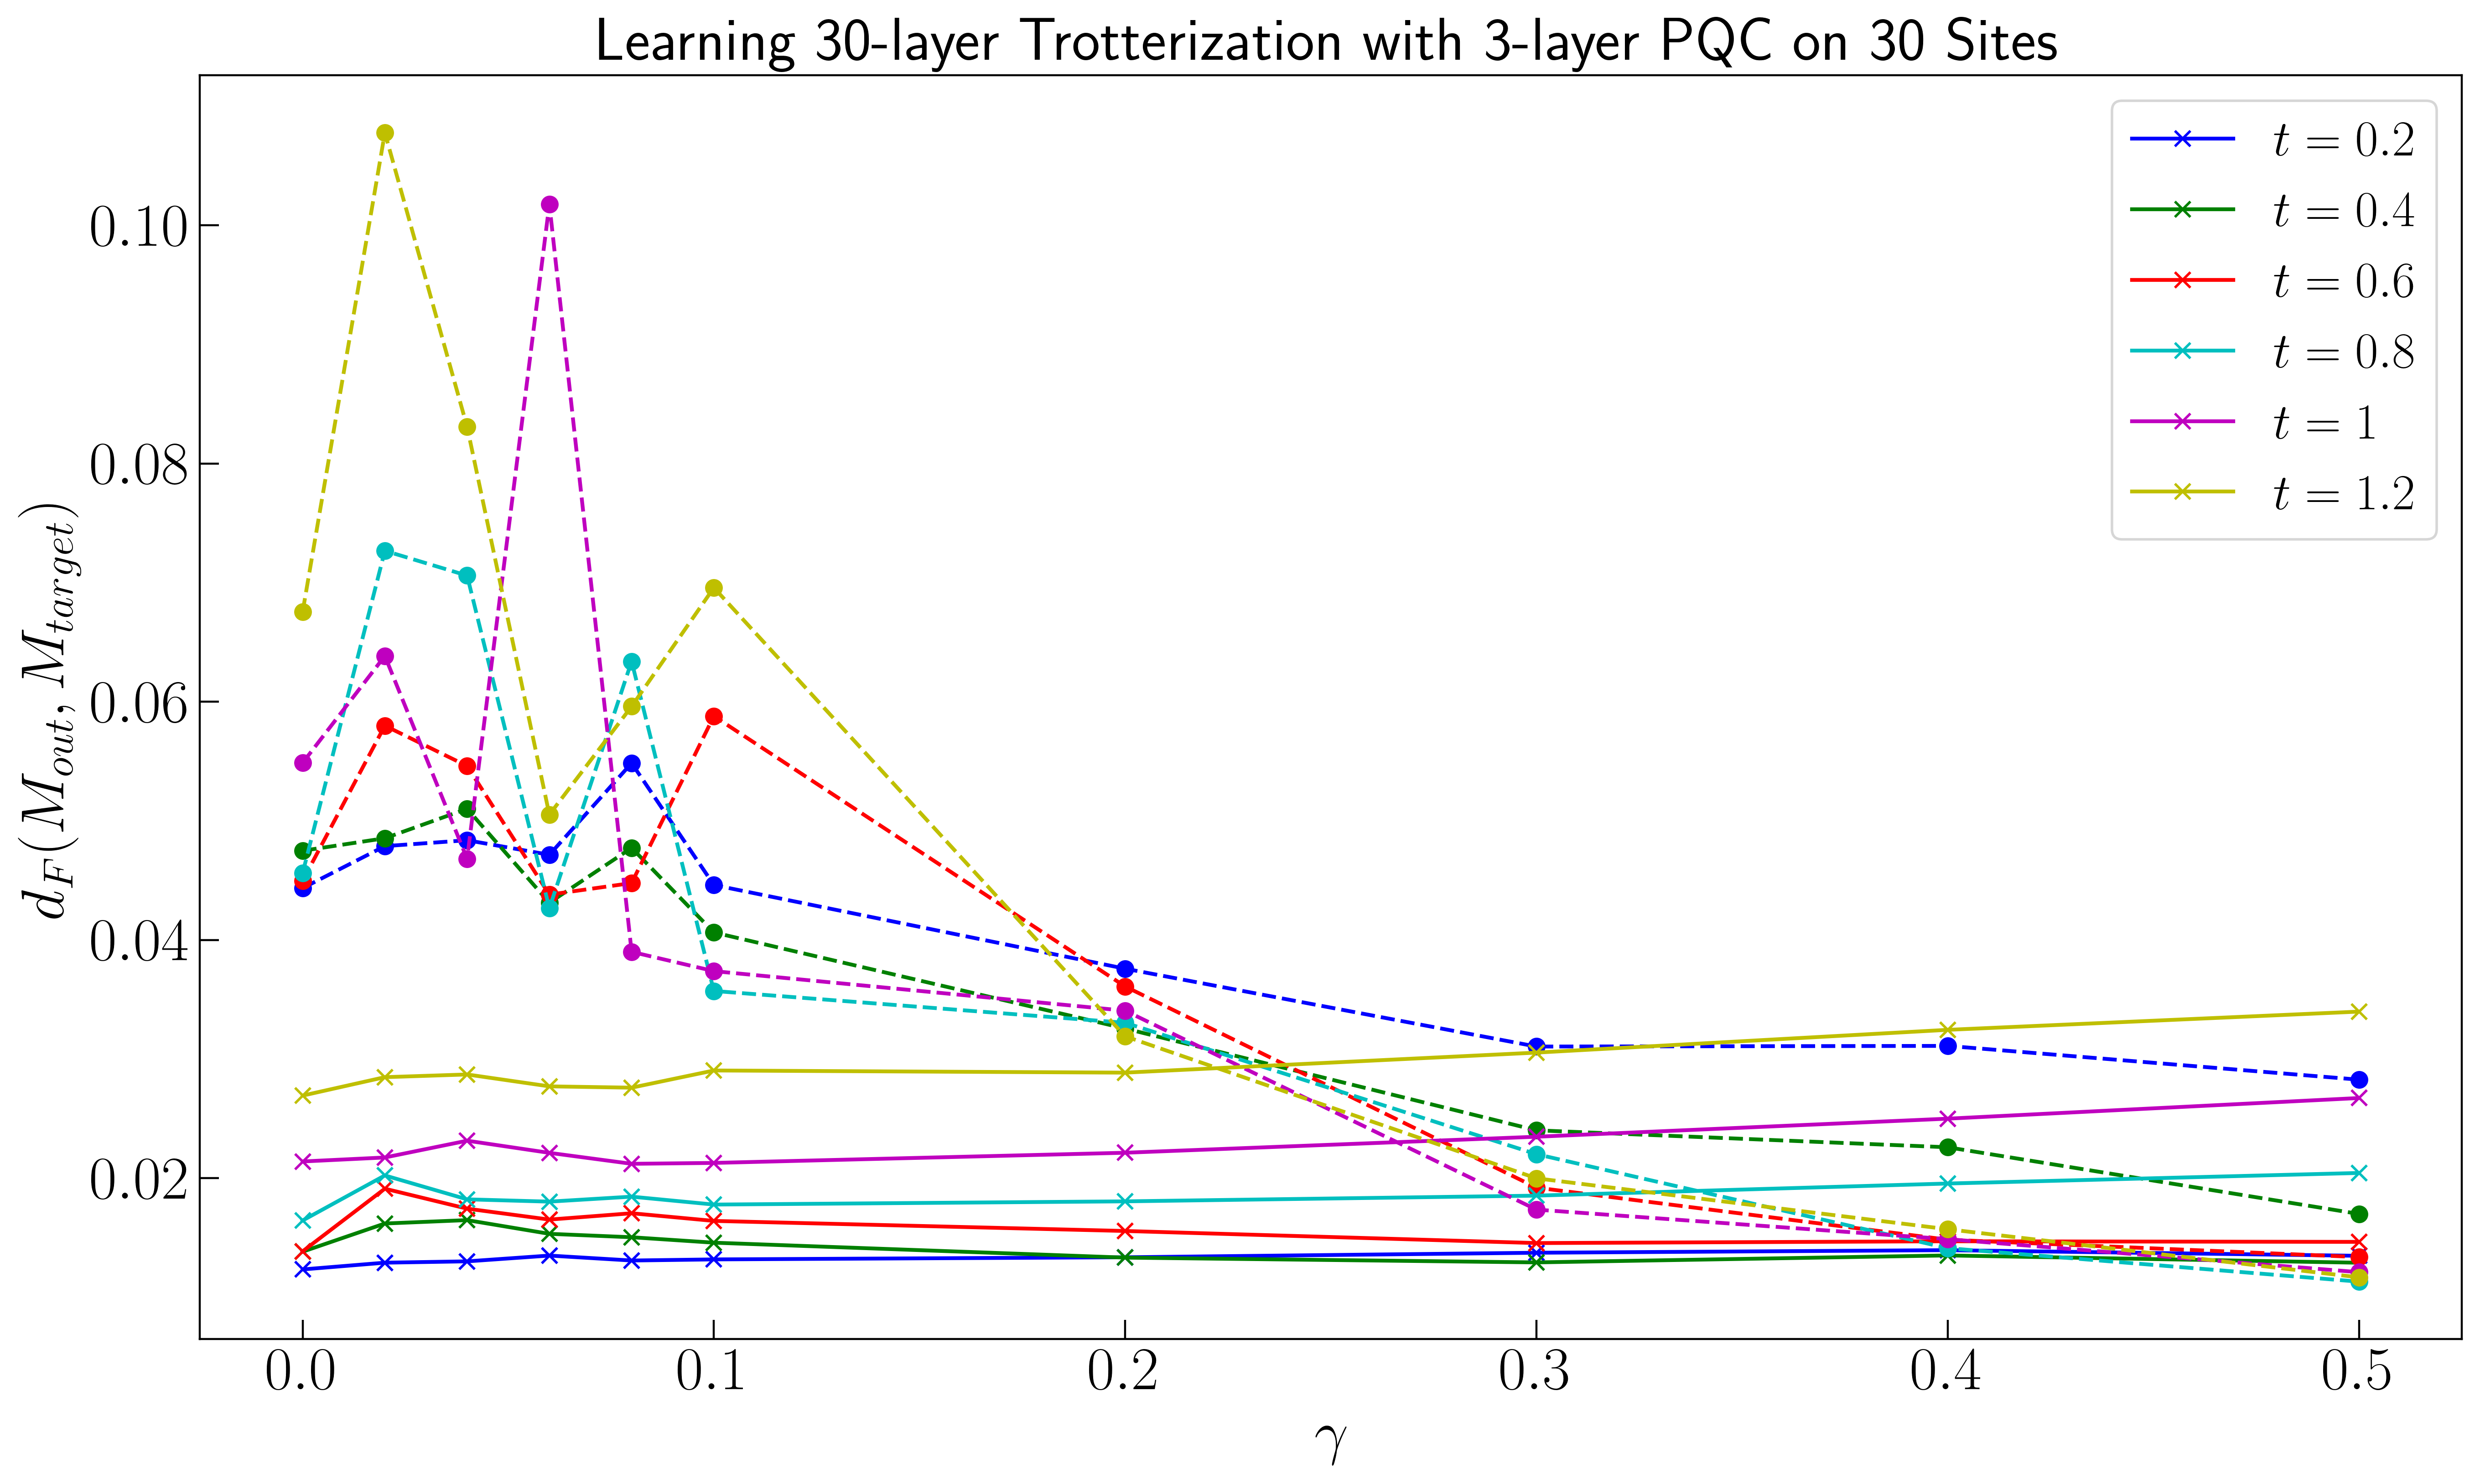

In [16]:
N = 30
T = 3
c_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
gamma_name_list = np.array([0, 2, 4, 6, 8, 10, 20, 30, 40, 50])
fig, ax = plt.subplots(1, 1)
counter = 0
for target_time in [0.2, 0.4, 0.6, 0.8, 1, 1.2]:
    i=0
    min_learning_loss_list = np.zeros(10)
    testing_loss_list = np.zeros(10)
    for gamma_name in gamma_name_list:
        prefix = f"TDME_N{N}_T{T}_time{target_time}_gamma{gamma_name:03d}"
        learning_loss = np.load(f"{prefix}_learning_loss.npy")
        testing_loss = np.load(f"{prefix}_testing_loss.npy")
        min_learning_loss_list[i] = min(learning_loss)
        testing_loss_list[i] = testing_loss
        i+=1
    ax.plot(gamma_name_list/100, min_learning_loss_list, marker = "x", c = c_list[counter], ls = "-", label = rf"$t = {target_time}$")
    ax.plot(gamma_name_list/100, testing_loss_list, c = c_list[counter], marker = "o", ls = "--")
    counter += 1
ax.legend(loc = "best", fontsize = 20)
ax.set_xlabel(r"$\gamma$", fontsize=24)
ax.set_ylabel(r'$d_F(M_{out}, M_{target})$', fontsize=24)
ax.set_title(f"Learning 30-layer Trotterization with 3-layer PQC on 30 Sites", fontsize=24)
plt.savefig(f"Figures/Learning_TDME_N_{N}_varies_gamma_time_02_12.pdf", dpi = 800)
plt.show()


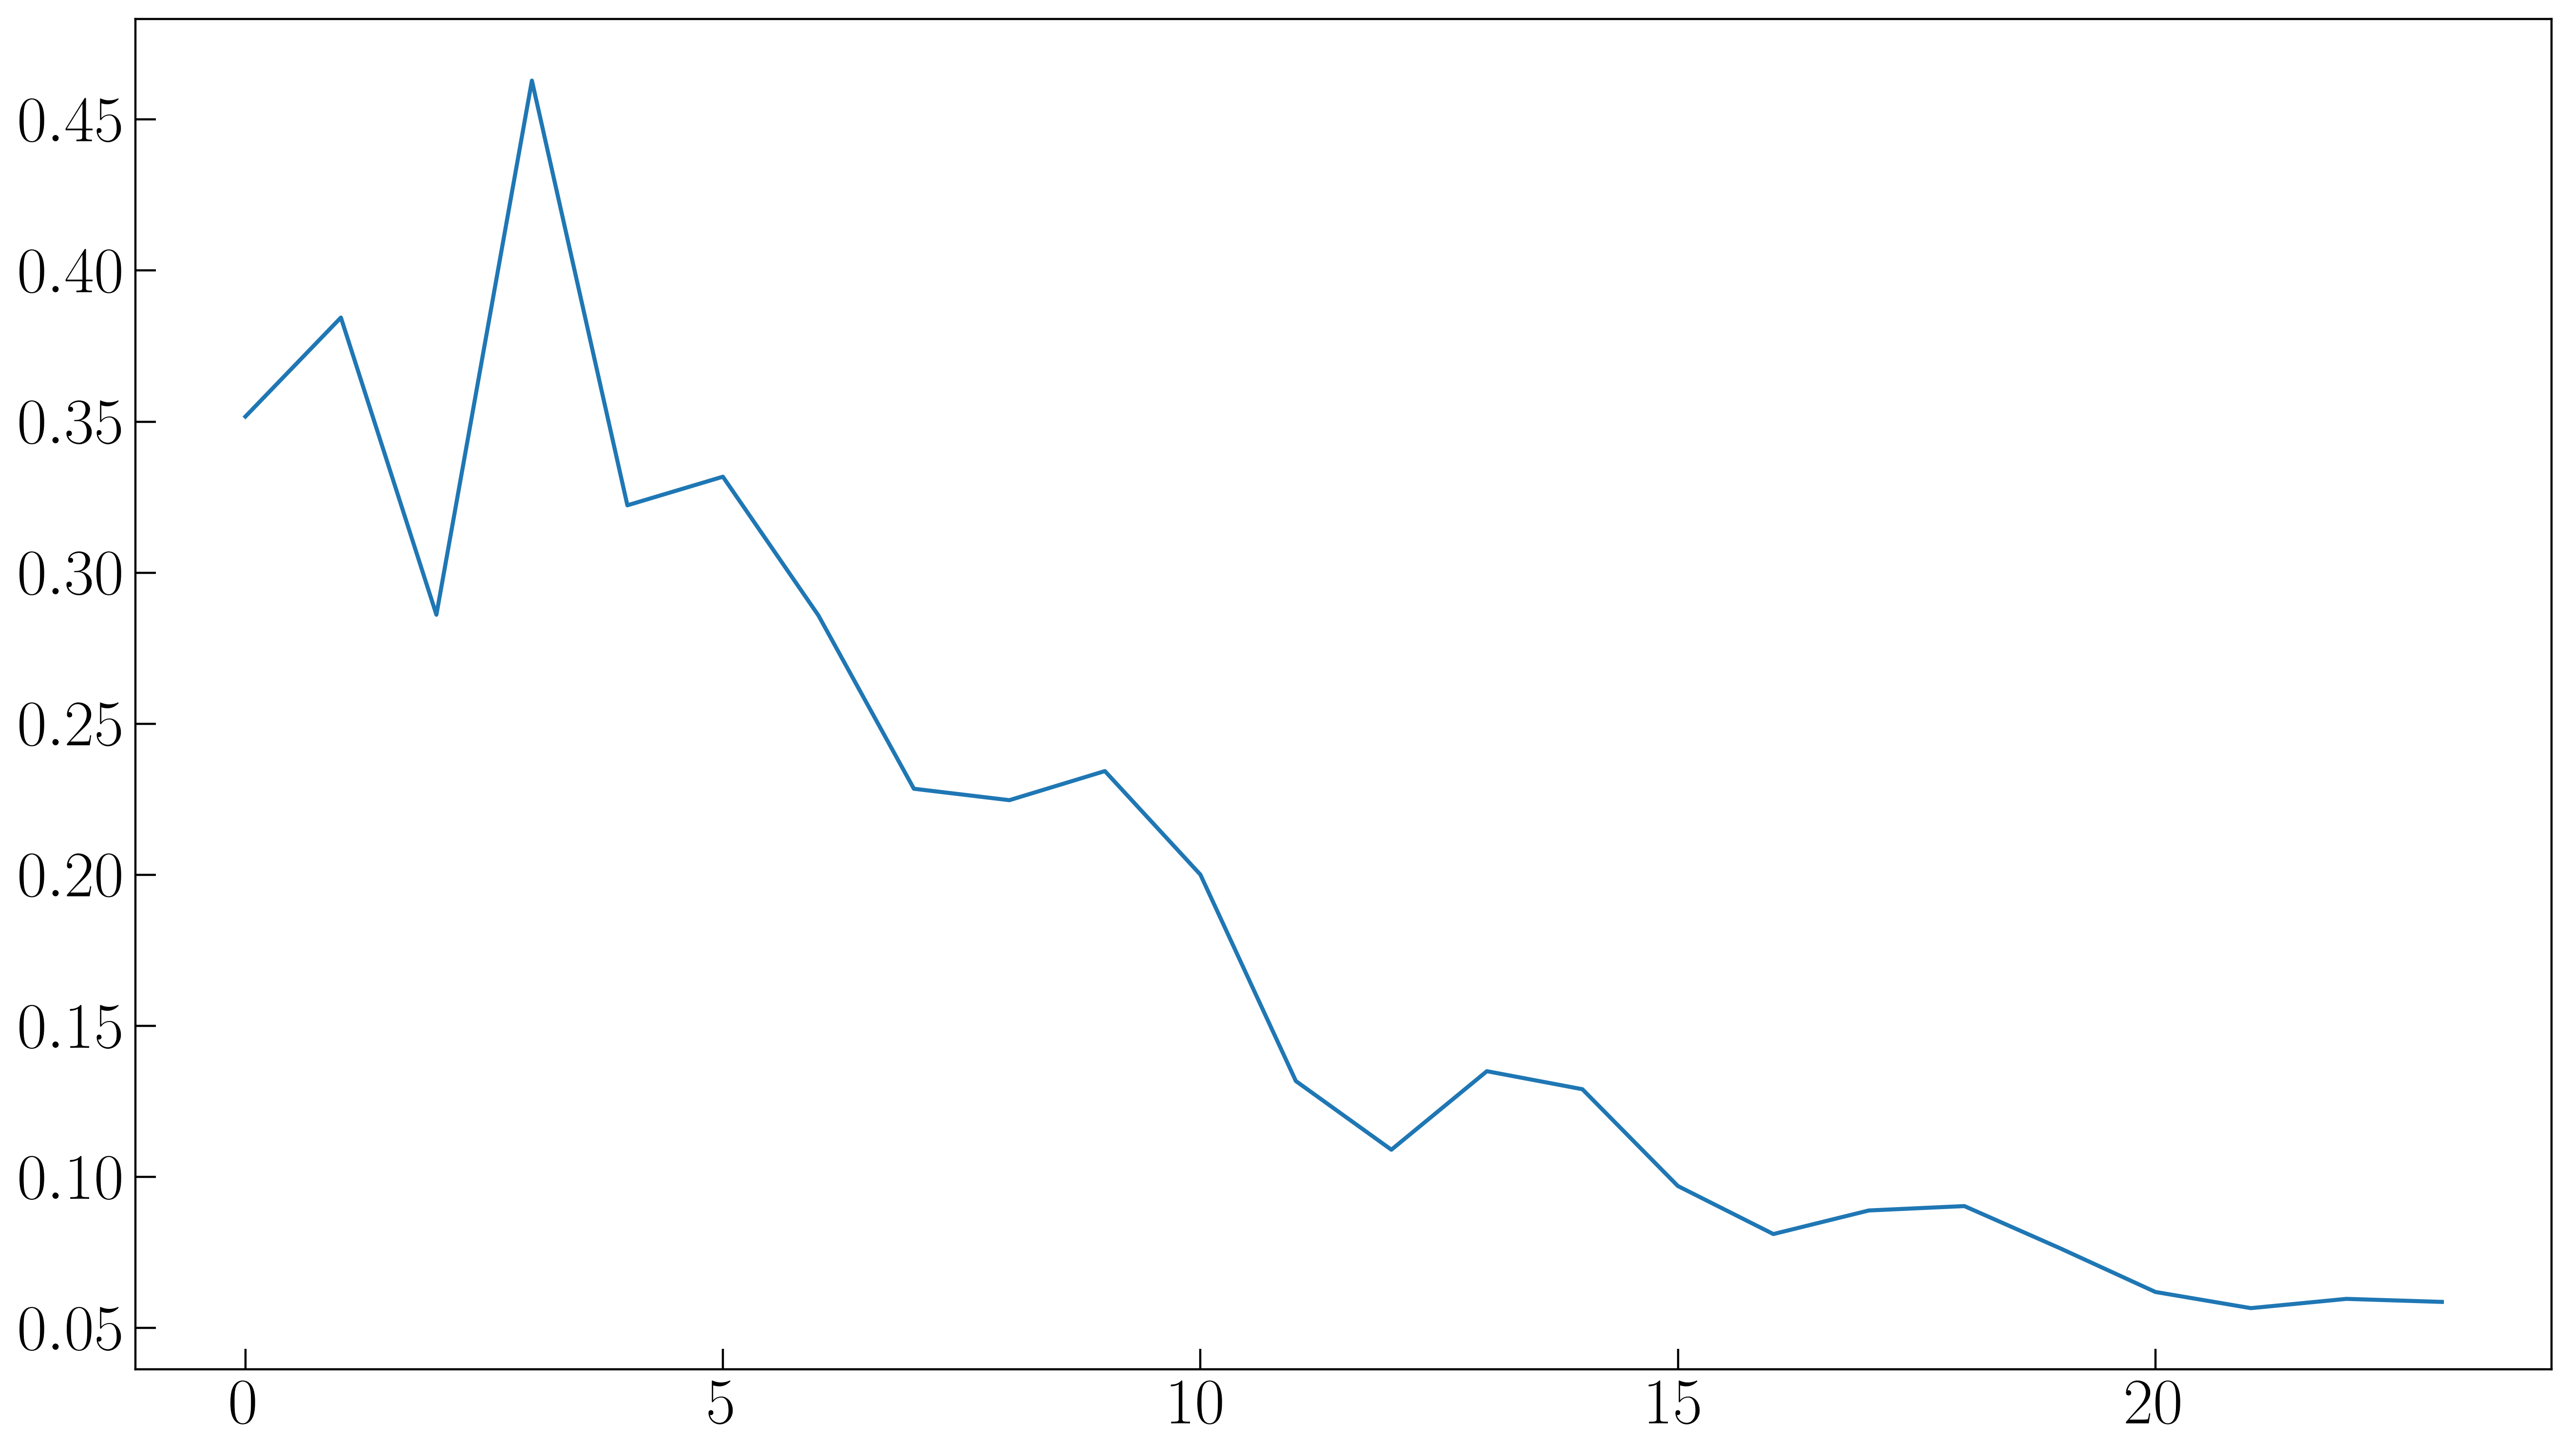

In [5]:
N = 30
T = 3
target_time = 0.2
gamma_name = 4
fig, ax = plt.subplots(1, 1)
prefix = f"TDME_N{N}_T{T}_time{target_time}_gamma{gamma_name:03d}"
learning_loss = np.load(f"{prefix}_learning_loss.npy")
ax.plot(np.arange(len(learning_loss)), learning_loss)
